Loading required package: stats4


Attaching package: ‘sn’


The following object is masked from ‘package:stats’:

    sd


Loading required package: usethis

Registered S3 methods overwritten by 'RcppEigen':
  method               from         
  predict.fastLm       RcppArmadillo
  print.fastLm         RcppArmadillo
  summary.fastLm       RcppArmadillo
  print.summary.fastLm RcppArmadillo

ℹ Updating exdqlm documentation
ℹ Loading exdqlm
ℹ Loading exdqlm
LDVB start | T=2000, p=6, tol=0.001 | KF:C++ | ELBO:on

iter   5 | maxDelta=1.28 | sigma=0.7 | gamma=-0.0019 | ELBO=-16943.380618 (Delta=-4.76e+01)

iter  10 | maxDelta=0.226 | sigma=0.727 | gamma=-0.000598 | ELBO=-17080.384129 (Delta=2.61e+01)

iter  15 | maxDelta=0.149 | sigma=0.814 | gamma=0.16 | ELBO=-16402.539164 (Delta=1.23e+02)

iter  20 | maxDelta=0.103 | sigma=0.855 | gamma=0.241 | ELBO=-16110.048069 (Delta=5.77e+01)

iter  25 | maxDelta=0.133 | sigma=0.898 | gamma=0.328 | ELBO=-15813.847943 (Delta=5.96e+01)

iter  30 | maxD

LDVB converged: 128 iterations, 97.407 seconds 


LDVB start | T=2000, p=6, tol=0.001 | KF:C++ | ELBO:on

iter   5 | maxDelta=3.88 | sigma=4.97 | gamma=0.00694 | ELBO=-9606.466017 (Delta=1.92e+02)

iter  10 | maxDelta=0.204 | sigma=4.97 | gamma=-0.0232 | ELBO=-9688.558794 (Delta=2.13e+01)

iter  15 | maxDelta=0.0515 | sigma=4.97 | gamma=-0.0299 | ELBO=-9660.197025 (Delta=2.38e+00)

iter  20 | maxDelta=0.0181 | sigma=4.96 | gamma=-0.0319 | ELBO=-9653.379573 (Delta=8.97e-01)

iter  25 | maxDelta=0.00628 | sigma=4.96 | gamma=-0.0326 | ELBO=-9650.810706 (Delta=3.29e-01)

iter  30 | maxDelta=0.00217 | sigma=4.96 | gamma=-0.0329 | ELBO=-9649.884126 (Delta=1.18e-01)



LDVB converged: 33 iterations, 23.482 seconds 


LDVB start | T=2000, p=6, tol=0.001 | KF:C++ | ELBO:on

iter   5 | maxDelta=2.38 | sigma=0.82 | gamma=0.000922 | ELBO=-17122.068759 (Delta=9.19e+01)

iter  10 | maxDelta=0.665 | sigma=0.952 | gamma=-0.0885 | ELBO=-16251.601051 (Delta=1.62e+02)

iter  15 | maxDelta=0.406 | sigma=1.07 | gamma=-0.258 | ELBO=-15661.938161 (Delta=1.09e+02)

iter  20 | maxDelta=0.283 | sigma=1.2 | gamma=-0.475 | ELBO=-15013.489987 (Delta=1.23e+02)

iter  25 | maxDelta=0.279 | sigma=1.35 | gamma=-0.759 | ELBO=-14321.793851 (Delta=1.32e+02)

iter  30 | maxDelta=0.444 | sigma=1.51 | gamma=-1.12 | ELBO=-13751.752316 (Delta=1.06e+02)

iter  35 | maxDelta=0.516 | sigma=1.68 | gamma=-1.56 | ELBO=-13234.765762 (Delta=1.01e+02)

iter  40 | maxDelta=0.423 | sigma=1.83 | gamma=-2.01 | ELBO=-12800.752453 (Delta=7.30e+01)

iter  45 | maxDelta=0.352 | sigma=1.93 | gamma=-2.39 | ELBO=-12564.343855 (Delta=3.17e+01)

iter  50 | maxDelta=0.222 | sigma=1.99 | gamma=-2.65 | ELBO=-12479.439331 (Delta=1.01e+01)

iter  55 | maxDel

LDVB converged: 84 iterations, 63.673 seconds 
            p0      MAE     RMSE      corr
p0=0.025 0.025 4.097706 4.569983 0.9985520
p0=0.500 0.500 2.763396 3.378175 0.9984512
p0=0.975 0.975 2.627556 3.227955 0.9992096


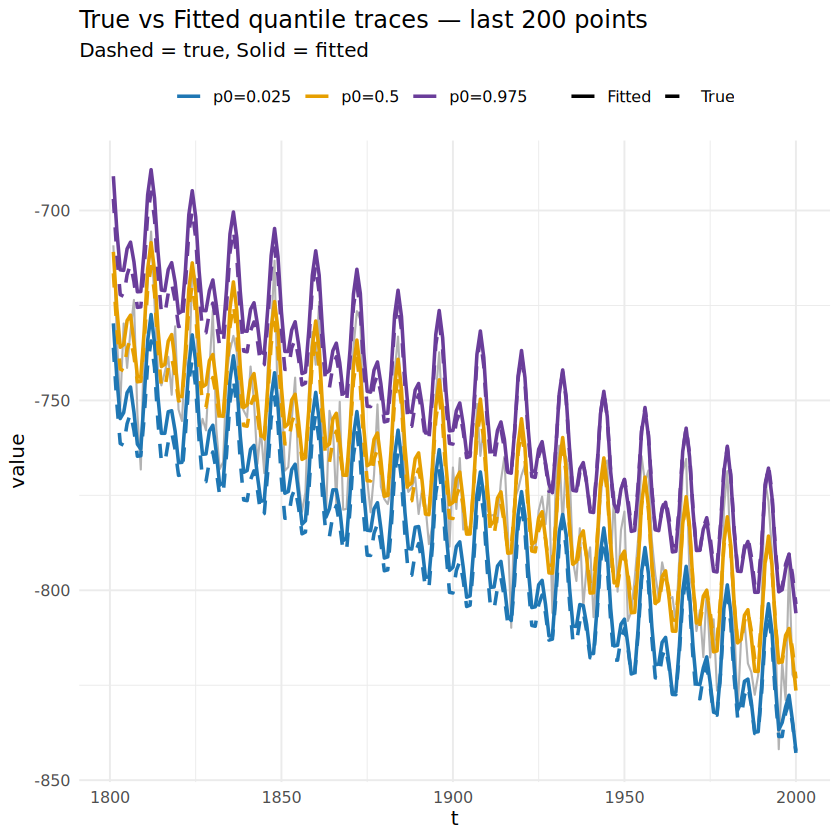

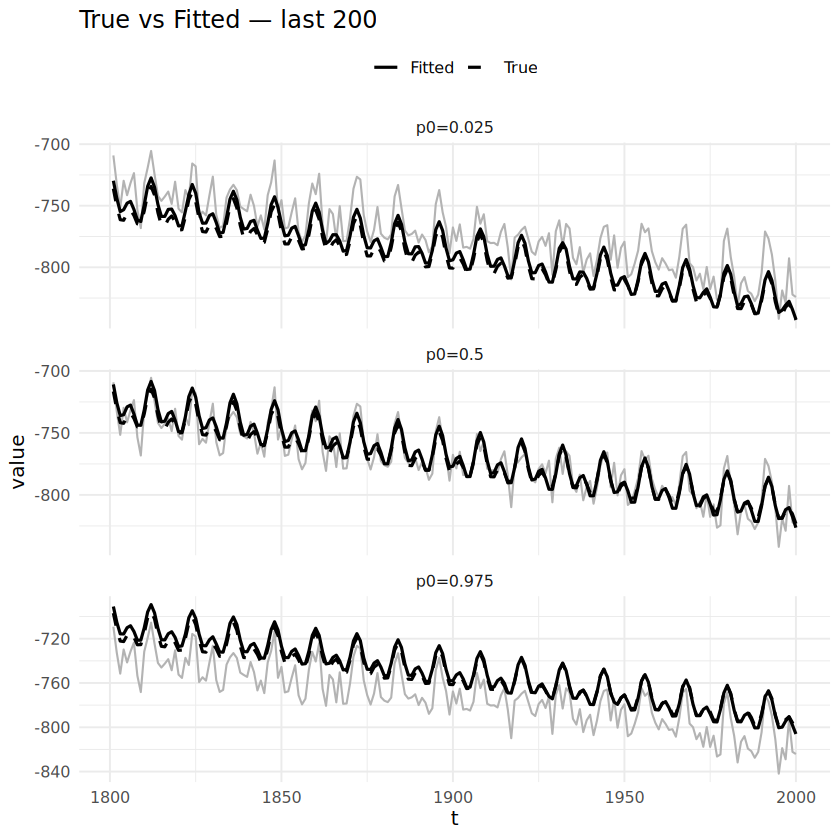

In [1]:
############################################################
# Quantile State-Space: Simulate -> LDVB(C++) fit -> Compare
############################################################

# ---- packages ----
# install.packages(c("mvtnorm","sn","ggplot2","tidyr","devtools","Rcpp","matrixStats"))
library(mvtnorm)
library(sn)
library(ggplot2)
library(tidyr)
library(devtools)
library(Rcpp)

# =========================================================
# A) SPEC (single place to configure simulation & fitting)
# =========================================================
spec <- list(
  # length and dimensions (base trend only; we'll augment with seasonals next)
  T   = 2000L,

  # Local linear trend (level+ slope): p=1, m_trend=2
  F   = matrix(c(1.0, 0.0), nrow = 1),                 # (1 x 2) load level, not slope
  G   = matrix(c(1, 1,
                 0, 1), nrow = 2, byrow = TRUE),       # (2 x 2)
  W   = diag(c(0.0001, 0.0001)),                           # (2 x 2)
  x0_mean = c(0, 0),                                   # (2,)
  x0_cov  = diag(0.1, 2),                              # (2 x 2)

  # Seasonal configuration (to be added to the state vector)
  seas_period    = 12L,            # monthly data → yearly seasonality
  seas_harmonics = c(1L, 2L),      # 1st and 2nd harmonic → 12- and 6-month cycles
  seas_q         = 1e-3,           # process noise variance per seasonal state (small)

  # # observation noise (you currently use var=100; leaving as-is)
  obs_noise  = "normal",
  obs_params = list(R = array(100, dim = c(1L, 1L))),
  # observation noise
  # obs_noise  = "exponential",
  # obs_params = list(scale = 100),   # var = scale^2 = 100; mean = 10; median ≈ 6.93


  # quantiles to carry through the simulation (must include any p0 you’ll fit)
  probs = c(0.025, 0.5, 0.975),

  # reproducibility
  seed = 42L
)

# =========================================================
# A2) Add two harmonic seasonal components (period = 12)
#     Each harmonic contributes a 2-state block:
#     G_j = [[cos λ,  sin λ],
#            [-sin λ, cos λ]],  λ = 2π j / period
#     F_j = [1, 0]  (load the first coord)
# =========================================================

# lightweight block-diagonal helper for square matrices
.block_diag <- function(...) {
  mats <- list(...)
  n <- sum(vapply(mats, nrow, 0L))
  out <- matrix(0, n, n)
  i <- 1L
  for (M in mats) {
    r <- nrow(M)
    out[i:(i+r-1), i:(i+r-1)] <- M
    i <- i + r
  }
  out
}

s  <- spec$seas_period
hs <- spec$seas_harmonics
lam <- 2*pi*hs/s

G_seas <- lapply(lam, function(l)
  matrix(c(cos(l), sin(l), -sin(l), cos(l)), nrow = 2, byrow = TRUE)
)
F_seas <- lapply(hs, function(.)
  matrix(c(1, 0), nrow = 1)  # load first coord of each harmonic
)
W_seas <- lapply(hs, function(.)
  diag(spec$seas_q, 2)
)

# assemble augmented state: [trend(2), seas1(2), seas2(2)] → m = 6
F_full <- do.call(cbind, c(list(spec$F), F_seas))            # (1 x 6)
G_full <- do.call(.block_diag, c(list(spec$G), G_seas))      # (6 x 6)
W_full <- do.call(.block_diag, c(list(spec$W), W_seas))      # (6 x 6)

x0_mean_full <- c(spec$x0_mean, 10, 0, 10, 0)                  # (6,)
x0_cov_full  <- .block_diag(spec$x0_cov, diag(0.1, 2), diag(0.1, 2))  # (6 x 6)

# overwrite spec with augmented F,G,W and initials
spec$F       <- F_full
spec$G       <- G_full
spec$W       <- W_full
spec$x0_mean <- x0_mean_full
spec$x0_cov  <- x0_cov_full

# ====================================================================
# B) Utilities: SPD guard, broadcaster, shape inspector, noise engines
# ====================================================================

.ensure_spd <- function(M, jitter = 1e-16) {
  S <- 0.5 * (M + t(M))
  ev <- eigen(S, symmetric = TRUE, only.values = TRUE)$values
  min_ev <- min(ev)
  if (min_ev <= jitter) S <- S + diag(jitter - min_ev + 1e-16, nrow(S))
  S
}

.as_timevarying <- function(M, T, expected_shape, name) {
  if (is.null(M)) return(NULL)

  if (is.function(M)) {
    out <- array(NA_real_, dim = c(T, expected_shape))
    for (t in seq_len(T)) {
      Mt <- as.matrix(M(t - 1L))
      if (!identical(dim(Mt), expected_shape)) {
        stop(sprintf("%s(t) has shape (%s), expected (%s)",
                     name, paste(dim(Mt), collapse=","), paste(expected_shape, collapse=",")))
      }
      out[t, , ] <- Mt
    }
    return(out)
  }

  arr <- as.array(M)
  d <- dim(arr)

  if (length(d) == length(expected_shape)) {
    out <- array(NA_real_, dim = c(T, expected_shape))
    for (t in seq_len(T)) out[t, , ] <- arr
    return(out)
  } else if (length(d) == length(expected_shape) + 1L) {
    if (d[1] != T || !identical(d[-1], expected_shape)) {
      stop(sprintf("%s has shape (%s), expected (T, %s)",
                   name, paste(d, collapse=","), paste(expected_shape, collapse=",")))
    }
    return(arr)
  } else {
    stop(sprintf("%s has invalid ndim=%d", name, length(d)))
  }
}

.peek_shape <- function(M) {
  if (is.function(M)) return(dim(as.matrix(M(0L))))
  arr <- as.array(M); d <- dim(arr)
  if (length(d) >= 2L) return(d[(length(d)-1L):length(d)])
  NULL
}

.draw_obs_noise <- function(T, p, kind = c("normal","skewnormal","exponential","cauchy"),
                            params = list()) {
  kind <- match.arg(tolower(kind), c("normal","skewnormal","exponential","cauchy"))

  if (kind == "normal") {
    R <- params$R
    if (!is.null(R)) {
      R <- as.array(R)
      if (length(dim(R)) == 2L) {
        stopifnot(all(dim(R) == c(p, p)))
        L <- chol(.ensure_spd(R))
        Z <- matrix(rnorm(T * p), nrow = T, ncol = p)
        return(Z %*% t(L))
      } else if (length(dim(R)) == 3L && all(dim(R)[1:2] == c(T, p)) && dim(R)[3] == p) {
        out <- matrix(NA_real_, nrow = T, ncol = p)
        for (t in seq_len(T)) {
          Lt <- chol(.ensure_spd(R[t, , , drop = TRUE]))
          out[t, ] <- as.numeric(Lt %*% rnorm(p))
        }
        return(out)
      } else stop("R must be (p,p) or (T,p,p)")
    }
    sigma <- params$sigma; if (is.null(sigma)) sigma <- 1
    sigma <- rep_len(as.numeric(sigma), p)
    return(matrix(rnorm(T * p, sd = rep(sigma, each = T)), nrow = T, ncol = p))
  }

  if (kind == "skewnormal") {
    alpha <- params$alpha; if (is.null(alpha)) alpha <- 0
    scale <- params$scale; if (is.null(scale)) scale <- 1
    loc   <- params$loc;   if (is.null(loc))   loc   <- 0
    alpha <- rep_len(as.numeric(alpha), p)
    scale <- rep_len(as.numeric(scale), p)
    loc   <- rep_len(as.numeric(loc),   p)
    out <- matrix(NA_real_, nrow = T, ncol = p)
    for (j in seq_len(p)) out[, j] <- rsn(T, xi = loc[j], omega = scale[j], alpha = alpha[j])
    return(out)
  }

  if (kind == "exponential") {
    scale <- params$scale; if (is.null(scale)) scale <- 1
    scale <- rep_len(as.numeric(scale), p)
    out <- matrix(NA_real_, nrow = T, ncol = p)
    for (j in seq_len(p)) out[, j] <- rexp(T, rate = 1 / scale[j])
    return(out)
  }

  if (kind == "cauchy") {
    scale <- params$scale; if (is.null(scale)) scale <- 1
    loc   <- params$loc;   if (is.null(loc))   loc   <- 0
    scale <- rep_len(as.numeric(scale), p)
    loc   <- rep_len(as.numeric(loc),   p)
    out <- matrix(NA_real_, nrow = T, ncol = p)
    for (j in seq_len(p)) out[, j] <- rcauchy(T, location = loc[j], scale = scale[j])
    return(out)
  }

  stop("Unknown observation noise kind")
}

.obs_noise_quantiles <- function(T, p, kind = c("normal","skewnormal","exponential","cauchy"),
                                 params = list(), probs) {
  kind <- match.arg(tolower(kind), c("normal","skewnormal","exponential","cauchy"))
  r <- length(probs)
  out <- array(NA_real_, dim = c(T, p, r))

  if (kind == "normal") {
    R <- params$R
    if (!is.null(R)) {
      R <- as.array(R)
      z <- qnorm(probs)
      if (length(dim(R)) == 2L && all(dim(R) == c(p, p))) {
        sd <- sqrt(pmax(0, diag(.ensure_spd(R))))
        for (k in seq_len(r)) out[, , k] <- matrix(sd * z[k], nrow = T, ncol = p, byrow = TRUE)
        return(out)
      } else if (length(dim(R)) == 3L && all(dim(R)[1:2] == c(T, p)) && dim(R)[3] == p) {
        sd_t <- matrix(NA_real_, nrow = T, ncol = p)
        for (t in seq_len(T)) {
          Rt <- .ensure_spd(R[t, , , drop = TRUE])
          sd_t[t, ] <- sqrt(pmax(0, diag(Rt)))
        }
        z <- qnorm(probs)
        for (k in seq_len(r)) out[, , k] <- sd_t * z[k]
        return(out)
      } else stop("R must be (p,p) or (T,p,p)")
    }
    sigma <- params$sigma; if (is.null(sigma)) sigma <- 1
    sigma <- rep_len(as.numeric(sigma), p)
    z <- qnorm(probs)
    for (k in seq_len(r)) out[, , k] <- matrix(sigma * z[k], nrow = T, ncol = p, byrow = TRUE)
    return(out)
  }

  if (kind == "skewnormal") {
    alpha <- params$alpha; if (is.null(alpha)) alpha <- 0
    scale <- params$scale; if (is.null(scale)) scale <- 1
    loc   <- params$loc;   if (is.null(loc))   loc   <- 0
    alpha <- rep_len(as.numeric(alpha), p)
    scale <- rep_len(as.numeric(scale), p)
    loc   <- rep_len(as.numeric(loc),   p)
    for (j in seq_len(p)) {
      out[, j, ] <- matrix(qsn(probs, xi = loc[j], omega = scale[j], alpha = alpha[j]),
                           nrow = T, ncol = r, byrow = TRUE)
    }
    return(out)
  }

  if (kind == "exponential") {
    scale <- params$scale; if (is.null(scale)) scale <- 1
    scale <- rep_len(as.numeric(scale), p)
    for (j in seq_len(p)) {
      out[, j, ] <- matrix(qexp(probs, rate = 1 / scale[j]),
                           nrow = T, ncol = r, byrow = TRUE)
    }
    return(out)
  }

  if (kind == "cauchy") {
    scale <- params$scale; if (is.null(scale)) scale <- 1
    loc   <- params$loc;   if (is.null(loc))   loc   <- 0
    scale <- rep_len(as.numeric(scale), p)
    loc   <- rep_len(as.numeric(loc),   p)
    for (j in seq_len(p)) {
      out[, j, ] <- matrix(qcauchy(probs, location = loc[j], scale = scale[j]),
                           nrow = T, ncol = r, byrow = TRUE)
    }
    return(out)
  }

  stop("Unknown observation noise kind")
}

# ==========================
# C) Simulator (Markov LSSM)
# ==========================
simulate_state_space <- function(
  T, F, G, W, x0_mean = NULL, x0_cov = NULL,
  obs_noise = c("normal","skewnormal","exponential","cauchy"),
  obs_params = list(), probs = NULL, seed = NULL
) {
  obs_noise <- match.arg(tolower(obs_noise), c("normal","skewnormal","exponential","cauchy"))
  if (!is.null(seed)) set.seed(seed)

  F_shape <- .peek_shape(F); G_shape <- .peek_shape(G)
  if (is.null(F_shape) || is.null(G_shape)) stop("Cannot infer shapes of F and G")
  p <- F_shape[1]; m_from_F <- F_shape[2]; m_from_G <- G_shape[1]
  if (m_from_F != m_from_G) stop(sprintf("State dim mismatch: F m=%d, G m=%d", m_from_F, m_from_G))
  m <- m_from_F

  Ft <- .as_timevarying(F, T, c(p, m), "F")
  Gt <- .as_timevarying(G, T, c(m, m), "G")
  Wt <- .as_timevarying(W, T, c(m, m), "W")

  if (is.null(x0_mean)) x0_mean <- rep(0, m)
  if (is.null(x0_cov))  x0_cov  <- matrix(0, m, m)
  stopifnot(all(dim(x0_cov) == c(m, m)))
  x_prev <- if (all(abs(x0_cov) < .Machine$double.eps)) {
    as.numeric(x0_mean)
  } else {
    as.numeric(rmvnorm(1, mean = x0_mean, sigma = .ensure_spd(x0_cov)))
  }

  X <- matrix(NA_real_, nrow = T, ncol = m)
  for (t in seq_len(T)) {
    Lw  <- chol(.ensure_spd(Wt[t, , , drop = TRUE]))
    w_t <- as.numeric(Lw %*% rnorm(m))
    x_t <- Gt[t, , , drop = TRUE] %*% x_prev + w_t
    X[t, ] <- x_t
    x_prev <- x_t
  }

  V <- .draw_obs_noise(T = T, p = p, kind = obs_noise, params = obs_params)
  Y_mean <- matrix(NA_real_, nrow = T, ncol = p)
  for (t in seq_len(T)) Y_mean[t, ] <- as.numeric(Ft[t, , , drop = TRUE] %*% X[t, ])
  Y <- Y_mean + V

  qY <- NULL
  if (!is.null(probs) && length(probs) > 0L) {
    qv <- .obs_noise_quantiles(T, p, obs_noise, params = obs_params, probs = probs)
    qY <- array(NA_real_, dim = dim(qv))
    for (k in seq_along(probs)) qY[, , k] <- Y_mean + qv[, , k]
  }

  list(x = X, y = Y, qy = qY)
}

# ======================================
# D) Plots: y with quantile lines (no band)
# ======================================
plot_y_with_quantiles <- function(res, title = "y_t with quantiles", probs = NULL) {
  stopifnot(!is.null(res$y))
  Tn <- nrow(res$y); p <- ncol(res$y); stopifnot(p >= 1L)

  df_y <- data.frame(
    t = rep(seq_len(Tn), times = p),
    j = rep(paste0("y[", seq_len(p), "]"), each = Tn),
    y = as.numeric(res$y)
  )
  g <- ggplot() +
    geom_line(data = df_y, aes(t, y), linewidth = 0.7, color = "black") +
    facet_wrap(~ j, scales = "free_y") +
    labs(x = "t", y = "value", title = title) +
    theme_minimal(base_size = 12)

  if (!is.null(res$qy)) {
    Tn <- dim(res$qy)[1]; p <- dim(res$qy)[2]; r <- dim(res$qy)[3]
    df_q <- data.frame(
      t = rep(seq_len(Tn), times = p * r),
      j = rep(paste0("y[", seq_len(p), "]"), each = Tn * r),
      k = rep(seq_len(r), each = Tn, times = p),
      q = as.numeric(res$qy)
    )
    if (!is.null(probs) && length(probs) == r) {
      labs_q <- paste0("p=", format(probs, trim = TRUE))
      df_q$qlab <- labs_q[df_q$k]
      mid_idx <- which.min(abs(probs - 0.5))
    } else {
      df_q$qlab <- paste0("q", df_q$k)
      mid_idx <- (r + 1L) %/% 2L
      labs_q <- unique(df_q$qlab)
    }
    df_q$is_mid <- df_q$k == mid_idx

    dist_from_mid <- abs(seq_len(r) - mid_idx)
    blues <- grDevices::colorRampPalette(c("#cfe0ff","#1f5fbf"))(max(1, r - 1))
    col_map <- setNames(rep(NA_character_, r), labs_q)
    if (r >= 2) {
      non_mid <- setdiff(seq_len(r), mid_idx)
      non_mid_by_dist <- non_mid[order(dist_from_mid[non_mid], non_mid)]
      col_map[labs_q[non_mid_by_dist]] <- blues
    }
    col_map[labs_q[mid_idx]] <- "#E69F00"

    df_q$size <- ifelse(df_q$is_mid, 0.9, 0.5)

    g <- g +
      geom_line(data = df_q, aes(x = t, y = q, color = qlab, group = interaction(j, qlab)),
                linewidth = df_q$size, show.legend = TRUE) +
      scale_color_manual(values = col_map, guide = guide_legend(title = "Quantiles"))
  }
  g
}

# =====================================================
# E) Posterior predictive zoom (base-R; efficient for T)
# =====================================================
pp_plot_zoom <- function(
  y, samples, p0,
  window = NULL,
  indices = NULL,
  backtransform = identity,
  conf = c(0.025, 0.975),
  spaghetti_n = 0,
  spaghetti_alpha = 0.2,
  col_band = "steelblue",
  col_q = "orange3",
  col_obs = "black",
  pch_obs = 16,
  cex_obs = 0.5,
  lwd_q = 3,
  main = "Posterior predictive (zoom)",
  xlab = "index", ylab = "y"
) {
  stopifnot(is.numeric(y), is.matrix(samples), length(p0) == 1, p0 > 0, p0 < 1)
  TT <- length(y)
  if (nrow(samples) != TT) { if (ncol(samples) == TT) samples <- t(samples) else stop("samples must be TT x ns or ns x TT.") }

  if (!is.null(indices)) idx <- intersect(indices, seq_len(TT))
  else if (!is.null(window)) idx <- seq.int(max(1, window[1]), min(TT, window[2]))
  else idx <- seq_len(TT)
  if (length(idx) < 2) stop("Need at least 2 points to plot.")

  Y <- y[idx]; S <- samples[idx, , drop = FALSE]
  probs <- sort(unique(c(conf[1], p0, conf[2])))
  if (requireNamespace("matrixStats", quietly = TRUE)) {
    Q <- matrixStats::rowQuantiles(S, probs = probs, na.rm = TRUE)
  } else {
    Q <- t(apply(S, 1, quantile, probs = probs, na.rm = TRUE))
  }
  il <- which.min(abs(probs - conf[1])); ih <- which.min(abs(probs - conf[2])); iq <- which.min(abs(probs - p0))

  Y_bt <- backtransform(Y)
  Q_lo <- backtransform(Q[, il]); Q_hi <- backtransform(Q[, ih]); Q_p0 <- backtransform(Q[, iq])

  x <- idx; ylim <- range(c(Y_bt, Q_lo, Q_hi), finite = TRUE)
  op <- par(mar = c(3.5, 4.2, 3, 1) + 0.1); on.exit(par(op), add = TRUE)
  plot(x, Y_bt, type = "n", xlab = xlab, ylab = ylab, main = main, ylim = ylim)
  polygon(c(x, rev(x)), c(Q_lo, rev(Q_hi)), border = NA, col = adjustcolor(col_band, alpha.f = 0.30))
  lines(x, Q_p0, lwd = lwd_q, lty = 1, col = col_q)
  if (spaghetti_n > 0) {
    ns <- ncol(S); keep <- if (spaghetti_n >= ns) seq_len(ns) else sample(ns, spaghetti_n)
    matlines(x, backtransform(S[, keep, drop = FALSE]), col = adjustcolor("grey20", spaghetti_alpha), lwd = 1)
  }
  points(x, Y_bt, pch = pch_obs, cex = cex_obs, col = col_obs)
  invisible(list(idx = idx, q_lo = Q_lo, q_p0 = Q_p0, q_hi = Q_hi))
}

# =========================================================
# F) Compare "true" vs "fitted" p0-quantile time series
# =========================================================
compare_true_vs_fitted <- function(
  res, samples, p0, sim_probs, window = NULL, y = NULL, backtransform = identity,
  title = "True vs Fitted p0-quantile"
) {
  stopifnot(!is.null(res$qy), is.numeric(p0), p0 > 0, p0 < 1)
  Tn <- dim(res$qy)[1]; p <- dim(res$qy)[2]; r <- dim(res$qy)[3]; stopifnot(p >= 1L)
  if (nrow(samples) != Tn) { if (ncol(samples) == Tn) samples <- t(samples) else stop("samples must be T x ns or ns x T.") }
  stopifnot(length(sim_probs) == r)

  idx <- if (is.null(window)) seq_len(Tn) else seq.int(max(1, window[1]), min(Tn, window[2]))
  k_true <- which.min(abs(sim_probs - p0))
  if (abs(sim_probs[k_true] - p0) > 1e-12) message(sprintf("p0=%.6g not in sim_probs; using nearest=%.6g", p0, sim_probs[k_true]))

  q_true <- res$qy[idx, 1, k_true]
  if (requireNamespace("matrixStats", quietly = TRUE)) {
    q_fit <- as.numeric(matrixStats::rowQuantiles(samples[idx, , drop = FALSE], probs = p0, na.rm = TRUE))
  } else {
    q_fit <- apply(samples[idx, , drop = FALSE], 1, quantile, probs = p0, na.rm = TRUE)
  }

  q_true_bt <- backtransform(q_true); q_fit_bt <- backtransform(q_fit)
  y_bt <- if (!is.null(y)) backtransform(y[idx]) else NULL

  mae  <- mean(abs(q_fit_bt - q_true_bt))
  rmse <- sqrt(mean((q_fit_bt - q_true_bt)^2))
  corv <- suppressWarnings(cor(q_fit_bt, q_true_bt))

  df <- data.frame(t = idx, true = q_true_bt, fit = q_fit_bt, obs = if (is.null(y_bt)) NA_real_ else y_bt)

  g <- ggplot(df, aes(x = t)) +
    { if (!is.null(y_bt)) geom_line(aes(y = obs), color = "grey75", linewidth = 0.6) } +
    geom_line(aes(y = true, color = "True p0"), linewidth = 1.0, linetype = "dashed") +
    geom_line(aes(y = fit,  color = "Fitted p0"), linewidth = 1.0) +
    scale_color_manual(values = c("True p0" = "black", "Fitted p0" = "#E69F00")) +
    labs(x = "t", y = "value",
         title = title,
         subtitle = sprintf("p0 = %.3g | MAE=%.4g, RMSE=%.4g, corr=%.3f", p0, mae, rmse, corv),
         color = NULL) +
    theme_minimal(base_size = 12) +
    theme(legend.position = "top")

  list(mae = mae, rmse = rmse, cor = corv, plot = g, df = df)
}

# =========================================================
# G) Dev: build & load exdqlm (C++ LDVB only, no IS used)
# =========================================================
pkg <- "~/code/exdqlm"  # adjust
stopifnot(file.exists(file.path(pkg, "DESCRIPTION")))

if ("exdqlm" %in% loadedNamespaces()) {
  detach("package:exdqlm", unload = TRUE, character.only = TRUE)
  unloadNamespace("exdqlm")
}
Rcpp::compileAttributes(pkgdir = pkg)
devtools::document(pkg)
devtools::load_all(pkg)

has_cpp_bridge <- exists("update_theta_bridge")
has_cpp_cpp    <- exists("update_theta_cpp")
stopifnot(has_cpp_bridge || has_cpp_cpp)

options(
  exdqlm.use_cpp_kf       = TRUE,   # C++ backend
  exdqlm.compute_elbo     = TRUE,
  exdqlm.tol_elbo         = 1e-6,
  exdqlm.use_cpp_samplers = FALSE,
  exdqlm.use_cpp_postpred = FALSE
)

# ===================================
# H) Simulate with the chosen SPEC
# ===================================
res <- simulate_state_space(
  T = spec$T, F = spec$F, G = spec$G, W = spec$W,
  x0_mean = spec$x0_mean, x0_cov = spec$x0_cov,
  obs_noise = spec$obs_noise, obs_params = spec$obs_params,
  probs = spec$probs, seed = spec$seed
)

# Optional overview plot (turn off for very large T)
# print(plot_y_with_quantiles(res, "Simulated y with quantiles", probs = spec$probs))

# ============================================
# I) Build exdqlm model to match the SPEC
# ============================================
m_dim <- nrow(spec$G)
model_from_spec <- structure(list(
  m0 = as.numeric(spec$x0_mean),
  C0 = as.matrix(spec$x0_cov),
  FF = as.numeric(spec$F),
  GG = as.matrix(spec$G),
  W  = as.matrix(spec$W)
), class = "exdqlm")

# Discount structure (single block covering all states)
dim_vec <- c(m_dim)
df_vec  <- c(0.9959)  # near 1: evolution close to GG; tune if needed

# Hyperparameters for LDVB (no single p0 here; we sweep later)
sig0    <- 0.1
gam0    <- 0
tol_val <- 0.001

# ===========================
# J) Fit LDVB at multiple p0s (window centered at t0)
# ===========================
p0_grid <- c(0.025, 0.5, 0.975)   # should be contained in spec$probs
TT      <- spec$T

# --- Window controls ---
t0      <- 2500L       # center index in [1, TT]  <-- adjust as you like
win_len <- 200L        # desired window length; we force it to be even below

# Force even so win_len/2 is an integer
if (win_len %% 2L == 1L) win_len <- win_len + 1L
half <- win_len %/% 2L

# Build a clamped, symmetric-as-possible window around t0.
compute_window <- function(TT, t0, half, win_len) {
  s <- t0 - half + 1L
  e <- t0 + half

  # clamp to [1, TT]
  if (s < 1L) {
    s <- 1L
    e <- min(TT, s + win_len - 1L)
  } else if (e > TT) {
    e <- TT
    s <- max(1L, e - win_len + 1L)
  }
  c(as.integer(s), as.integer(e))
}

win <- compute_window(TT, t0, half, win_len)
win_width <- win[2] - win[1] + 1L   # actual width (may be < win_len near edges)

fit_one_p0 <- function(p0_level, window_vec) {
  set.seed(2)  # reproducible per run
  fit <- exdqlmLDVB(
    y        = as.numeric(res$y[,1]),  # p=1
    p0       = p0_level,
    model    = model_from_spec,
    df       = df_vec,
    dim.df   = dim_vec,
    sig.init = sig0,
    gam.init = gam0,
    tol      = tol_val,
    n.samp   = 10000,
    verbose  = TRUE
  )

  cmp <- compare_true_vs_fitted(
    res        = res,
    samples    = fit$samp.post.pred,
    p0         = p0_level,
    sim_probs  = spec$probs,
    window     = window_vec,  # <-- centered & clamped window
    y          = as.numeric(res$y[,1]),
    backtransform = identity,
    title      = sprintf("True vs Fitted (p0=%.3f) — t ∈ [%d,%d] (n=%d)",
                         p0_level, window_vec[1], window_vec[2],
                         window_vec[2] - window_vec[1] + 1L)
  )

  list(p0 = p0_level, fit = fit, cmp = cmp, window = window_vec)
}

fits <- lapply(p0_grid, function(p) fit_one_p0(p, win))
names(fits) <- paste0("p0=", format(p0_grid))

# ===========================
# K) Metrics table
# ===========================
metrics <- data.frame(
  p0   = p0_grid,
  MAE  = vapply(fits, function(z) z$cmp$mae,  numeric(1)),
  RMSE = vapply(fits, function(z) z$cmp$rmse, numeric(1)),
  corr = vapply(fits, function(z) z$cmp$cor,  numeric(1))
)
print(metrics)

# ===========================
# L) Combined comparison plot
#     (overlay true vs fitted for all p0’s)
# ===========================
# Gather last-window traces for all p0’s
df_list <- lapply(fits, function(z) {
  df <- z$cmp$df  # columns: t, true, fit, obs
  df$p0 <- z$p0
  tidyr::pivot_longer(df, c(true, fit), names_to = "type", values_to = "q")
})

df_all <- do.call(rbind, df_list)
df_all$p0_lab <- factor(df_all$p0, levels = p0_grid,
                        labels = paste0("p0=", c("0.025","0.5","0.975")))

# One obs line (identical across models)
obs_df <- fits[[1]]$cmp$df[, c("t","obs")]
obs_df <- obs_df[is.finite(obs_df$obs), , drop = FALSE]

# Colors per p0; dashed = true, solid = fitted
col_map <- c(
  "p0=0.025" = "#1f77b4",
  "p0=0.5"   = "#E69F00",
  "p0=0.975" = "#6a3d9a"
)

g_all <- ggplot() +
  { if (nrow(obs_df)) geom_line(data = obs_df, aes(t, obs),
                                color = "grey70", linewidth = 0.6) } +
  geom_line(
    data = df_all,
    aes(x = t, y = q, color = p0_lab, linetype = type),
    linewidth = 1.0
  ) +
  scale_linetype_manual(values = c(true = "dashed", fit = "solid"),
                        labels = c(true = "True", fit = "Fitted"),
                        name = NULL) +
  scale_color_manual(values = col_map, name = NULL) +
  labs(
    x = "t", y = "value",
    title = sprintf("True vs Fitted quantile traces — last %d points", half * 2),
    subtitle = "Dashed = true, Solid = fitted"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "top")
print(g_all)

# (Optional) Faceted version (one panel per p0)
g_facet <- ggplot() +
  { if (nrow(obs_df)) geom_line(data = obs_df, aes(t, obs),
                                color = "grey70", linewidth = 0.6) } +
  geom_line(
    data = df_all,
    aes(x = t, y = q, linetype = type),
    color = "black", linewidth = 0.9
  ) +
  facet_wrap(~ p0_lab, ncol = 1, scales = "free_y") +
  scale_linetype_manual(values = c(true = "dashed", fit = "solid"),
                        labels = c(true = "True", fit = "Fitted"), name = NULL) +
  labs(x = "t", y = "value",
       title = sprintf("True vs Fitted — last %d",  half * 2)) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "top")
print(g_facet)


ℹ Updating exdqlm documentation
ℹ Loading exdqlm
ℹ Loading exdqlm


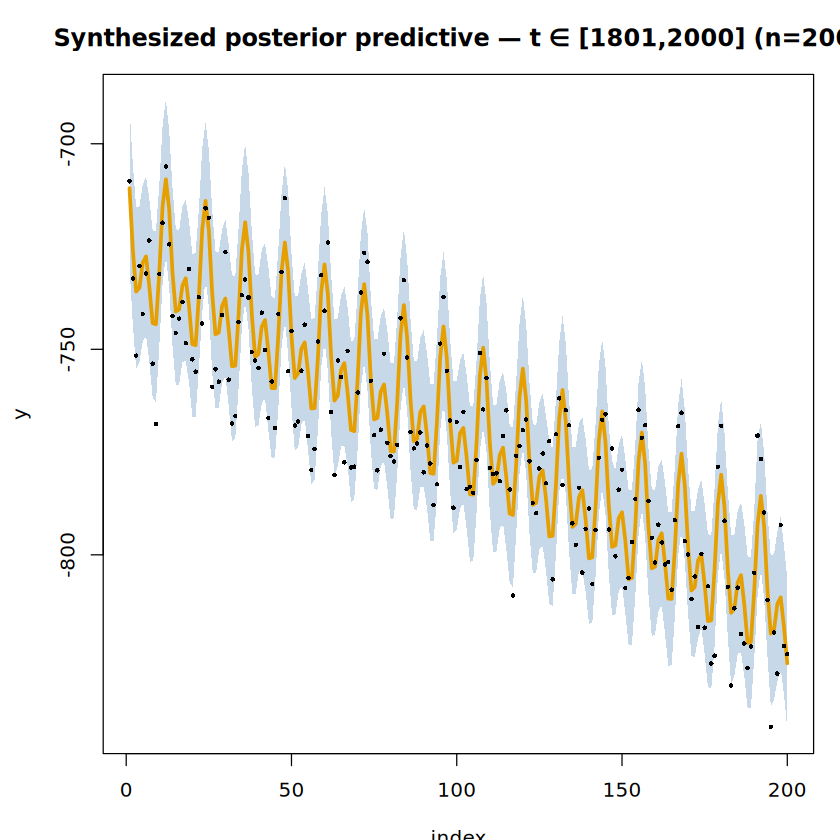

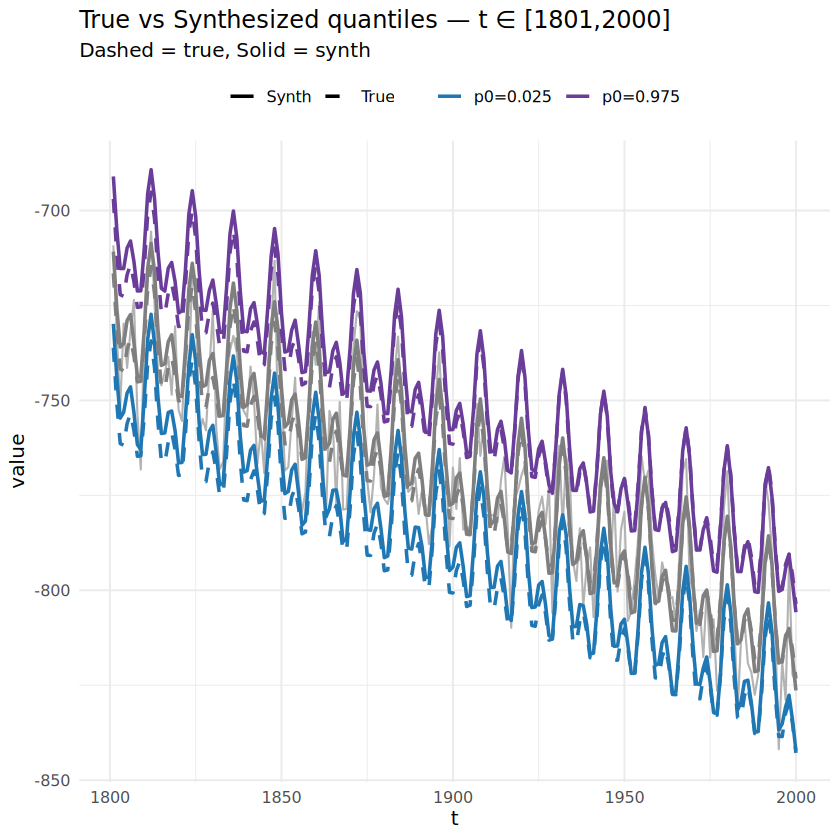

In [2]:
devtools::document()
devtools::load_all()

# ===========================
# M) Collect posterior predictive draws from each fitted p0
# ===========================
draws_list <- lapply(fits, function(z) z$fit$samp.post.pred)  # list of T×ns (or ns×T)

# ===========================
# N) Synthesize (isotonic + rearrangement) and zoom plot
# ===========================
T_expected <- nrow(res$y)  # enforce correct time dimension

synth <- exdqlm_synthesize_from_draws(
  draws_list       = draws_list,
  p                = p0_grid,
  enforce_isotonic = TRUE,
  rearrange        = TRUE,
  grid_M           = 1001L,
  n_samp           = 10000L,
  seed             = 123,
  T_expected       = T_expected   
)

# quick sanity
stopifnot(nrow(synth$draws) == T_expected)

# Align to your window and plot without 'window='
idx_win       <- seq.int(win[1], win[2])
draws_syn_win <- as.matrix(synth$draws[idx_win, , drop = FALSE])
y_win         <- as.numeric(res$y[idx_win, 1])

pp_plot_zoom(
  y             = y_win,
  samples       = draws_syn_win,
  p0            = 0.5,
  window        = NULL,            # <- already aligned via idx_win
  backtransform = identity,
  conf          = c(0.025, 0.975),
  spaghetti_n   = 0,
  col_band      = "steelblue",
  col_q         = "#E69F00",
  col_obs       = "black",
  lwd_q         = 3,
  main = sprintf("Synthesized posterior predictive — t ∈ [%d,%d] (n=%d)",
                  win[1], win[2], length(idx_win)),
  xlab = "index", ylab = "y"
)


# ===========================
# O) True vs Synthesized quantile traces (same window/style)
# ===========================
idx  <- idx_win
rowQ <- function(M, prob) {
  if (requireNamespace("matrixStats", quietly = TRUE)) {
    as.numeric(matrixStats::rowQuantiles(M, probs = prob, na.rm = TRUE))
  } else {
    apply(M, 1L, quantile, probs = prob, na.rm = TRUE)
  }
}

df_syn_list <- lapply(seq_along(p0_grid), function(i) {
  p0i   <- p0_grid[i]
  k_true <- which.min(abs(spec$probs - p0i))
  q_true <- res$qy[idx, 1, k_true]
  q_syn  <- rowQ(synth$draws[idx, , drop = FALSE], p0i)
  data.frame(
    t    = idx,
    q    = c(q_true, q_syn),
    type = rep(c("true", "synth"), each = length(idx)),
    p0   = p0i
  )
})
df_syn <- do.call(rbind, df_syn_list)
df_syn$p0_lab <- factor(df_syn$p0, levels = p0_grid,
                        labels = paste0("p0=", format(p0_grid, trim = TRUE)))

obs_df2 <- fits[[1]]$cmp$df[, c("t", "obs")]
obs_df2 <- obs_df2[obs_df2$t %in% idx & is.finite(obs_df2$obs), , drop = FALSE]

col_map <- c("p0=0.025"="#1f77b4","p0=0.5"="#E69F00","p0=0.975"="#6a3d9a")

g_syn <- ggplot() +
  { if (nrow(obs_df2)) geom_line(data = obs_df2, aes(t, obs),
                                 color = "grey70", linewidth = 0.6) } +
  geom_line(
    data = df_syn,
    aes(x = t, y = q, color = p0_lab, linetype = type),
    linewidth = 1.0
  ) +
  scale_linetype_manual(values = c(true = "dashed", synth = "solid"),
                        labels = c(true = "True", synth = "Synth"), name = NULL) +
  scale_color_manual(values = col_map, name = NULL) +
  labs(x = "t", y = "value",
       title = sprintf("True vs Synthesized quantiles — t ∈ [%d,%d]", win[1], win[2]),
       subtitle = "Dashed = true, Solid = synth") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "top")
print(g_syn)
